In [3]:
import os
import sys
import json
import numpy as np

sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used,split_by_musicianship,load_results_with_exclusion_no_dropping, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability, estimate_split_half_reliability, compute_itemwise_split_half_reliability_by_isi
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir, plot_groupwise_item_response_scatter, plot_power_curve_sem, plot_itemwise_hit_fa_relationship

from utls.reliability import compute_power_curve
from utls.plotting import plot_power_curve, plot_dprime_by_isi#, plot_groupwise_item_response_scatter
from utls.encoders import *

from utls.runners_utils import *


import os, random
import matplotlib.pyplot as plt

from scipy.stats import norm
import pandas as pd

from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

def compute_itemwise_dprime(df_hits, df_fas, eps=1e-5):
    # Ensure identical column sets
    common = sorted(set(df_hits.columns) & set(df_fas.columns))
    df_hits = df_hits[common]
    df_fas  = df_fas[common]

    hit_rates = df_hits.mean(axis=0).clip(eps, 1-eps)
    fa_rates  = df_fas.mean(axis=0).clip(eps, 1-eps)

    # Force pandas Series output
    dprime_values = norm.ppf(hit_rates.values) - norm.ppf(fa_rates.values)
    return pd.Series(dprime_values, index=common)

def compute_dprime_for_subjects(df, subject_list):
    """
    Returns ISIs and d' curve for a selected subset of subjects.
    """
    df_sub = df[df["subject"].isin(subject_list)]
    return compute_dprime_curve(df_sub)

def split_half_reliability(df, n_splits=1000, seed=0, method="pearson"):
    """
    df: per-subject-per-ISI dataframe (with hit_rate + fa_rate)
    n_splits: number of random half-splits
    method: pearson or spearman
    
    Returns dict with:
        correlations: list of correlations across splits
        mean_r: mean reliability
        ci: 95% bootstrap CI
    """

    rng = np.random.default_rng(seed)
    df = df[df["isi"] != -1].copy()
    subjects = df["subject"].unique()
    n = len(subjects)

    correlations = []

    for _ in range(n_splits):
        # random split
        rng.shuffle(subjects)
        half1 = subjects[: n//2]
        half2 = subjects[n//2 :]

        # compute d' for each split
        isis1, d1 = compute_dprime_for_subjects(df, half1)
        isis2, d2 = compute_dprime_for_subjects(df, half2)

        # ensure ISIs match exactly
        assert np.all(isis1 == isis2)

        # pick correlation type
        if method == "pearson":
            r = np.corrcoef(d1, d2)[0, 1]
        else:
            from scipy.stats import spearmanr
            r = spearmanr(d1, d2).correlation

        correlations.append(r)

    correlations = np.array(correlations)
    ci = np.percentile(correlations, [2.5, 97.5])

    # Spearman–Brown correction (optional):
    # corrected = 2*mean_r / (1 + mean_r)
    # include if needed

    return {
        "correlations": correlations,
        "mean_r": correlations.mean(),
        "ci": ci,
        "raw": correlations
    }

def power_analysis(df, 
                   min_n=6, 
                   max_n=None, 
                   n_repeats=300, 
                   seed=0, 
                   method="pearson"):
    """
    Compute how split-half reliability increases with number of participants.

    Parameters
    ----------
    df : DataFrame (subject x ISI summary rows)
    min_n : smallest N of subjects to test
    max_n : largest N to test (defaults to all participants)
    n_repeats : bootstrap repetitions per N
    method : pearson or spearman

    Returns
    -------
    dict containing:
        Ns : array of sample sizes tested
        r_mean : mean reliability per N
        r_ci_low, r_ci_high : 95% CIs
        r_mat : full matrix (n_Ns x n_repeats)
    """
    df = df[df["isi"] != -1].copy()
    rng = np.random.default_rng(seed)
    subjects = np.array(df["subject"].unique())
    total_subj = len(subjects)

    if max_n is None:
        max_n = total_subj

    Ns = np.arange(min_n, max_n + 1)
    
    # storage
    r_mat = np.zeros((len(Ns), n_repeats))

    for idx, N in enumerate(Ns):
        for k in range(n_repeats):
            # sample N participants without replacement
            chosen = rng.choice(subjects, size=N, replace=False)

            # split into halves
            rng.shuffle(chosen)
            half1 = chosen[: N//2]
            half2 = chosen[N//2 :]

            # compute curves
            isis1, d1 = compute_dprime_for_subjects(df, half1)
            isis2, d2 = compute_dprime_for_subjects(df, half2)

            # remove NaNs and constant vectors
            valid = ~(np.isnan(d1) | np.isnan(d2))
            d1v, d2v = d1[valid], d2[valid]
            if len(d1v) < 2 or np.std(d1v) == 0 or np.std(d2v) == 0:
                r = np.nan
            else:
                if method == "pearson":
                    r = np.corrcoef(d1v, d2v)[0,1]
                else:
                    from scipy.stats import spearmanr
                    r = spearmanr(d1v, d2v).correlation

            r_mat[idx, k] = r

    # compute summary
    r_mean = np.nanmean(r_mat, axis=1)
    r_ci_low = np.nanpercentile(r_mat, 2.5, axis=1)
    r_ci_high = np.nanpercentile(r_mat, 97.5, axis=1)

    return {
        "Ns": Ns,
        "r_mean": r_mean,
        "r_ci_low": r_ci_low,
        "r_ci_high": r_ci_high,
        "r_mat": r_mat
    }

def _clip(p, eps=1e-5):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()

def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)

def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def _clip(p, eps=1e-2):
    return np.clip(p, eps, 1 - eps)

def compute_population_fa_rate(df):
    """
    df must contain per-subject aggregated rows with column 'fa_rate'.
    We compute the mean FA rate ACROSS subjects (not pooled).
    """
    return df["fa_rate"].mean()

def compute_population_hit_rates_by_isi(df):
    """
    df must contain columns: isi, hit_rate.
    We compute mean hit rate across subjects for each ISI.
    Returns Series indexed by ISI.
    """
    return df.groupby("isi")["hit_rate"].mean().sort_index()


def compute_dprime_from_rates(hit, fa):
    hit = _clip(hit)
    fa = _clip(fa)
    return norm.ppf(hit) - norm.ppf(fa)

def compute_Aprime(hit, fa):
    """
    Compute nonparametric A' (A-prime) from hit and false-alarm rates.
    Takes vectorized or scalar hit/fa inputs.

    Equivalent to Snodgrass & Corwin (1988).
    """

    hit = np.asarray(hit)
    fa = np.asarray(fa)

    # Avoid division-by-zero edge cases
    eps = 1e-9
    hit = np.clip(hit, eps, 1 - eps)
    fa  = np.clip(fa,  eps, 1 - eps)

    A = np.zeros_like(hit, dtype=float)

    mask = hit >= fa
    A[mask] = 0.5 + ((hit[mask] - fa[mask]) * (1 + hit[mask] - fa[mask])) / (4 * hit[mask] * (1 - fa[mask]))
    A[~mask] = 0.5 - ((fa[~mask] - hit[~mask]) * (1 + fa[~mask] - hit[~mask])) / (4 * fa[~mask] * (1 - hit[~mask]))

    return A


def compute_dprime_curve(df):
    """
    df is your per-subject-per-isi summary df.
    """
    fa = compute_population_fa_rate(df)
    hit_rates = compute_population_hit_rates_by_isi(df)

    isis = hit_rates.index.to_numpy()
    dp = np.array([compute_dprime_from_rates(h, fa) for h in hit_rates.values])
    return isis, dp

# ============================================
# Bootstrapping
# ============================================

def bootstrap_dprime(df, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)

    subjects = df["subject"].unique()
    isis, _ = compute_dprime_curve(df)
    n_isi = len(isis)

    boot_mat = np.zeros((n_boot, n_isi))

    for b in range(n_boot):
        # sample subjects
        sampled = rng.choice(subjects, size=len(subjects), replace=True)

        # create bootstrapped df
        df_s = df[df["subject"].isin(sampled)]

        # recompute d'
        _, dp = compute_dprime_curve(df_s)
        boot_mat[b] = dp

    mean_dp = boot_mat.mean(axis=0)
    sem_dp = boot_mat.std(axis=0, ddof=1)
    ci_low = np.percentile(boot_mat, 2.5, axis=0)
    ci_high = np.percentile(boot_mat, 97.5, axis=0)

    return {
        "isis": isis,
        "mean": mean_dp,
        "sem": sem_dp,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "boot_matrix": boot_mat,
    }

def p_to_star(p):
    if p < 1e-4: return f"**** p={p:.3f}"
    if p < 1e-3: return f"*** p={p:.3f}"
    if p < 0.01: return f"** p={p:.3f}"
    if p < 0.05: return f"* p={p:.3f}"
    return f"n.s. p={p:.3f}"

def run_analysis(df, n_boot=5000):
    # Remove unwanted ISI
    df_removed = df[df["isi"] != -1].copy()
    isis, dp = compute_dprime_curve(df_removed)
    boot = bootstrap_dprime(df_removed, n_boot=n_boot)
    N = df_removed["subject"].nunique()

    hrs = compute_population_hit_rates_by_isi(df)
    fa  = compute_population_fa_rate(df)
    return {
        "isis": isis,
        "dprime": dp,
        "boot": boot,
        "hrs": hrs,
        "fa": fa,
        "N": N
    }

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:720: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:720: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:953: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"{title} ($\mu={mu:.3f}$)")


In [4]:
# results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# results = list(results)

tasks = ["env-sounds" ,"glob-music", "atexts", "nhs-region-len120"]
 # "global-music-len120", "atexts-len120" "nhs-region-len120"
base_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/len120_multi/"
seqs_paths = {"env-sounds": "mem_exp_ind-nature_2025", 
              "glob-music": "global-music-2025-n_80",
              "atexts": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"env-sounds": "Industrial and Nature", 
              "glob-music": "Globalized Music",
              "atexts": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}

which_task = tasks[2]
exps, seqs, fnames, skipped_exps, skipped_seqs, skipped_fnames = load_experiment_data(2, None, True)
# (f"/mindhive/mcdermott/www/bjmedina/experiments/{which_task}/results/{which_task}/len120_multi",
#                                                     min_dprime=2,
#                                                     min_trials=120,
#                                                     skip_len60=True,
#                                                     verbose=True,
#                                                     return_skipped=True)


x_textures = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, 1,2,4,8,16,32,64]
x_textures = x_textures[x_textures['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x_textures.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);



which_task = tasks[1]
exps, seqs, fnames, skipped_exps, skipped_seqs, skipped_fnames = load_experiment_data(1, None, True)


x_music = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, 1,2,4,8,16,32,64]
x_music = x_music[x_music['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x_music.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);



which_task = tasks[0]
exps, seqs, fnames, skipped_exps, skipped_seqs, skipped_fnames = load_experiment_data(0, None, True)

x_env = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, 1,2,4,8,16,32,64]
x_env = x_env[x_env['isi'].isin(valid_isi_values)].copy()
#plt.hist(x_filtered.isi.tolist(), bins=len(valid_isi_values))
x_env.groupby(["subject", "isi", "n_signal"]).size().unstack(fill_value=0);





safe_name = "all".lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/figures/human-results/multi-isi", safe_name)

ensure_dir(save_dir)
print(save_dir)

TypeError: list indices must be integers or slices, not str

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import norm

out_env = run_analysis(x_env)
out_music = run_analysis(x_music)
out_textures = run_analysis(x_textures)


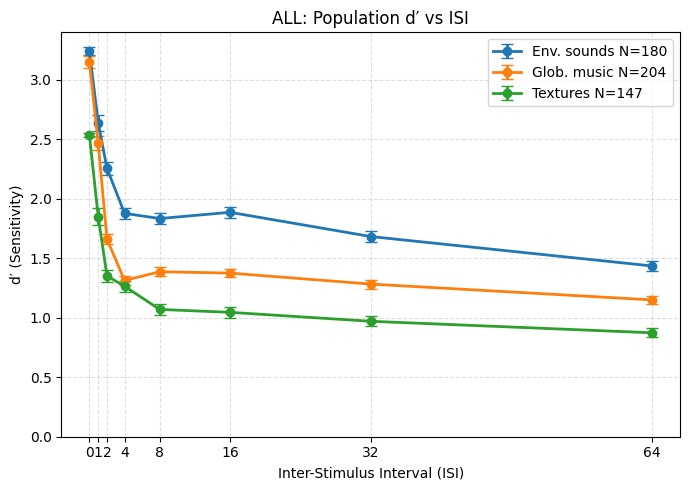

In [10]:
names = ["Env. sounds", "Glob. music", "Textures"]
plt.figure(figsize=(7,5))
grid = np.array([0,1,2,4,8,16,32,64])


for out, name in zip([out_env, out_music, out_textures], names):

    isis = out["isis"]
    dprime = out["dprime"]
    boot = out["boot"]
    
    plt.errorbar(
        isis,
        dprime,
        yerr=boot["sem"],
        fmt='o-',
        capsize=4,
        linewidth=2,
        markersize=6,
        label=name+f" N={out["N"]}"
    )
    
    # Find the y-position slightly above both points
    y_max = max(dprime[list(isis).index(16)], dprime[list(isis).index(64)])
    y_sig = y_max + 0.05  # adjust as needed
    
    isi_plot_dir = os.path.join(save_dir, "dprime-vs-isi.png")

plt.legend()
plt.xticks(isis, isis)
plt.ylim(bottom=0)
plt.xlabel("Inter-Stimulus Interval (ISI)")
plt.ylabel("d′ (Sensitivity)")
plt.title("ALL: Population d′ vs ISI")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(isi_plot_dir)
plt.show()


Scaling parameters:
  Music → Env:    a=0.807, b=0.715, r=0.978
  Textures → Env: a=1.024, b=0.703, r=0.981


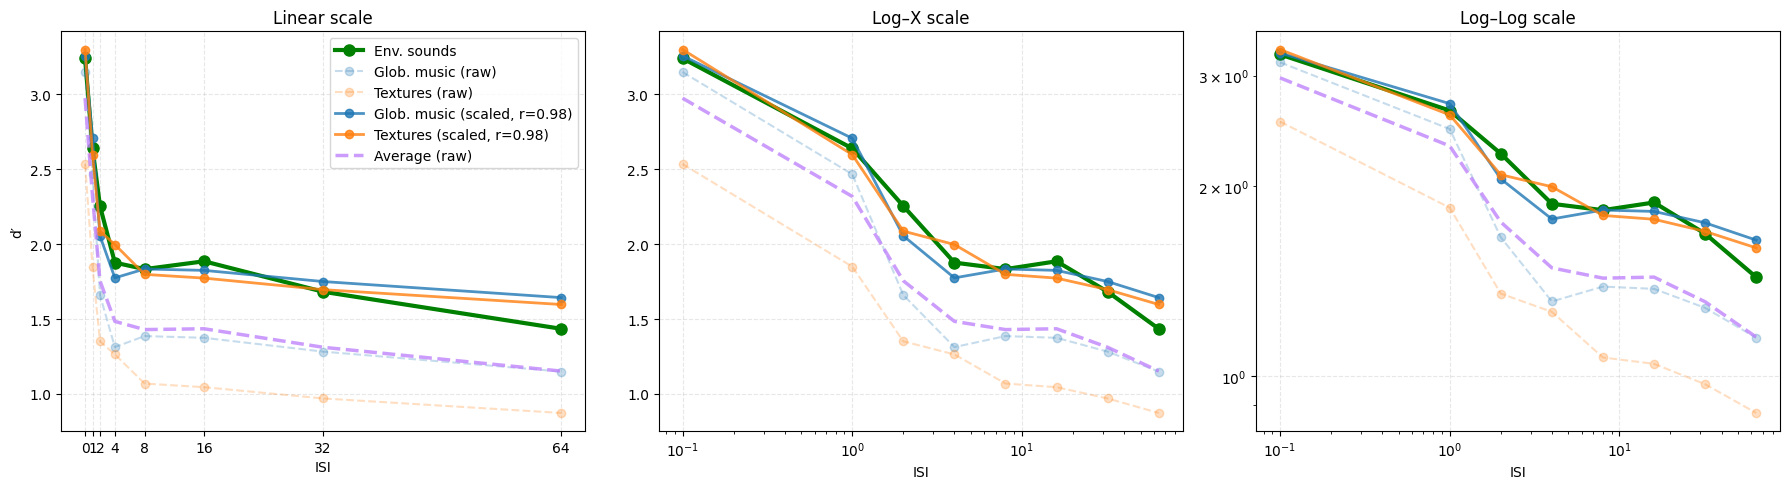

In [11]:
# --------------------------------------------
# Extract raw curves
# --------------------------------------------
grid = np.array([0,1,2,4,8,16,32,64])

isis_env    = np.array(out_env["isis"])
dp_env      = np.array(out_env["dprime"])
isis_music  = np.array(out_music["isis"])
dp_music    = np.array(out_music["dprime"])
isis_text   = np.array(out_textures["isis"])
dp_text     = np.array(out_textures["dprime"])

# --------------------------------------------
# Interpolate everything onto a shared grid
# --------------------------------------------
env_curve     = np.interp(grid, isis_env, dp_env)
music_curve   = np.interp(grid, isis_music, dp_music)
texture_curve = np.interp(grid, isis_text, dp_text)

# --------------------------------------------
# Fit linear scaling (music → env)
# --------------------------------------------
X = music_curve.reshape(-1,1)
y = env_curve
lr = LinearRegression().fit(X, y)
a_m = lr.coef_[0]
b_m = lr.intercept_
scaled_music = a_m * music_curve + b_m

# correlation (music scaled vs env)
r_m, _ = pearsonr(scaled_music, env_curve)

# --------------------------------------------
# Fit linear scaling (textures → env)
# --------------------------------------------
X = texture_curve.reshape(-1,1)
y = env_curve
lr = LinearRegression().fit(X, y)
a_t = lr.coef_[0]
b_t = lr.intercept_
scaled_texture = a_t * texture_curve + b_t

# correlation (textures scaled vs env)
r_t, _ = pearsonr(scaled_texture, env_curve)

print("\nScaling parameters:")
print(f"  Music → Env:    a={a_m:.3f}, b={b_m:.3f}, r={r_m:.3f}")
print(f"  Textures → Env: a={a_t:.3f}, b={b_t:.3f}, r={r_t:.3f}")

# --------------------------------------------
# COLOR SETTINGS
# --------------------------------------------
col_env      = "green"
col_music    = "#1f77b4"
col_music_s  = col_music
col_text     = "#ff7f0e"
col_text_s   = col_text
col_avg      = "#c084fc"   # 🔵 light purple


# --------------------------------------------
# FIX FOR LOG AXES: replace 0 → 0.1
# --------------------------------------------
grid_log = grid.astype(float).copy()
grid_log[grid_log == 0] = 0.1   # small positive substitute

# --------------------------------------------
# 3-PANEL FIGURE
# --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=False)


# --------------------------------------------
# 🔵 AVERAGE CURVE (raw curves)
# --------------------------------------------
avg_curve = (env_curve + music_curve + texture_curve) / 3.0
avg_curve_log = np.maximum(avg_curve, 1e-4)   # for log-log panel

# ============================================================
# (1) Linear–Linear
# ============================================================
ax = axes[0]

ax.plot(grid, env_curve, 'o-', linewidth=3, markersize=8,
        label="Env. sounds", color=col_env)

ax.plot(grid, music_curve,   'o--', alpha=0.25,
        label="Glob. music (raw)", color=col_music)
ax.plot(grid, texture_curve, 'o--', alpha=0.25,
        label="Textures (raw)", color=col_text)

ax.plot(grid, scaled_music, 'o-', linewidth=2, alpha=0.8,
        label=f"Glob. music (scaled, r={r_m:.2f})", color=col_music_s)
ax.plot(grid, scaled_texture, 'o-', linewidth=2, alpha=0.8,
        label=f"Textures (scaled, r={r_t:.2f})", color=col_text_s)

# 🔵 average curve
ax.plot(grid, avg_curve, '--', linewidth=2.5, alpha=0.8,
        label="Average (raw)", color=col_avg)

ax.set_title("Linear scale")
ax.set_xlabel("ISI")
ax.set_ylabel("d′")
ax.set_xticks(grid)
ax.grid(True, ls="--", alpha=0.3)
ax.legend()



# ============================================================
# (2) Log-X panel
# ============================================================
ax = axes[1]

ax.plot(grid_log, env_curve, 'o-', linewidth=3, markersize=8,
        label="Env. sounds", color=col_env)

ax.plot(grid_log, music_curve,   'o--', alpha=0.25, color=col_music)
ax.plot(grid_log, texture_curve, 'o--', alpha=0.25, color=col_text)

ax.plot(grid_log, scaled_music,   'o-', linewidth=2, alpha=0.8, color=col_music_s)
ax.plot(grid_log, scaled_texture, 'o-', linewidth=2, alpha=0.8, color=col_text_s)

# 🔵 average curve
ax.plot(grid_log, avg_curve, '--', linewidth=2.5, alpha=0.8,
        label="Average (raw)", color=col_avg)

ax.set_xscale("log")
ax.set_title("Log–X scale")
ax.set_xlabel("ISI")
ax.grid(True, ls="--", alpha=0.3)



# ============================================================
# (3) Log–Log panel
# ============================================================
eps = 1e-2
env_c_log     = np.maximum(env_curve, eps)
scaled_m_log  = np.maximum(scaled_music, eps)
scaled_t_log  = np.maximum(scaled_texture, eps)
music_log     = np.maximum(music_curve, eps)
text_log      = np.maximum(texture_curve, eps)

ax = axes[2]

ax.plot(grid_log, env_c_log, 'o-', linewidth=3, markersize=8,
        label="Env. sounds", color=col_env)

ax.plot(grid_log, music_log, 'o--', alpha=0.25, color=col_music)
ax.plot(grid_log, text_log,  'o--', alpha=0.25, color=col_text)

ax.plot(grid_log, scaled_m_log, 'o-', linewidth=2, alpha=0.8, color=col_music_s)
ax.plot(grid_log, scaled_t_log, 'o-', linewidth=2, alpha=0.8, color=col_text_s)

# 🔵 average curve
ax.plot(grid_log, avg_curve_log, '--', linewidth=2.5, alpha=0.8,
        label="Average (raw)", color=col_avg)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Log–Log scale")
ax.set_xlabel("ISI")
ax.grid(True, ls="--", alpha=0.3)

# ============================================================
# SAVE + SHOW
# ============================================================
plt.tight_layout()
out_path = os.path.join(save_dir, "universality_scaled_curves_all_scales.png")
plt.savefig(out_path)
plt.show()

In [33]:
# ============================================
# MODEL FITTING FOR AVERAGE CURVE
# ============================================

# target = average curve
target = avg_curve.copy()

# Safe ISI versions
isi = grid.astype(float)
isi_no0 = np.where(isi == 0, 0.1, isi)  # avoids log(0)

# --------------------------------------------------
# 1. Linear fit: d' = a + b * ISI
# --------------------------------------------------
X_lin = isi.reshape(-1,1)
lr = LinearRegression().fit(X_lin, target)
pred_lin = lr.predict(X_lin)
r2_lin = lr.score(X_lin, target)

# --------------------------------------------------
# 2. Logarithmic fit: d' = a + b * log(ISI + 1)
# --------------------------------------------------
X_log = np.log(isi_no0 + 1).reshape(-1,1)
lr = LinearRegression().fit(X_log, target)
pred_log = lr.predict(X_log)
r2_log = lr.score(X_log, target)

# --------------------------------------------------
# 3. Power-law fit: log(d') = A + B * log(ISI)
# --------------------------------------------------
target_pos = np.maximum(target, 1e-4)
X_pow = np.log(isi_no0).reshape(-1,1)
y_pow = np.log(target_pos)

lr = LinearRegression().fit(X_pow, y_pow)
pred_pow_log = lr.predict(X_pow)
pred_pow = np.exp(pred_pow_log)

# compute R² manually since model was fit in log space
r2_pow = 1 - np.sum((target_pos - pred_pow)**2) / np.sum((target_pos - np.mean(target_pos))**2)

print("\n=== MODEL FIT COMPARISON (Average Curve) ===")
print(f"Linear model R²:       {r2_lin:.3f}")
print(f"Logarithmic model R²:  {r2_log:.3f}")
print(f"Power-law model R²:    {r2_pow:.3f}")


=== MODEL FIT COMPARISON (Average Curve) ===
Linear model R²:       0.369
Logarithmic model R²:  0.740
Power-law model R²:    0.946


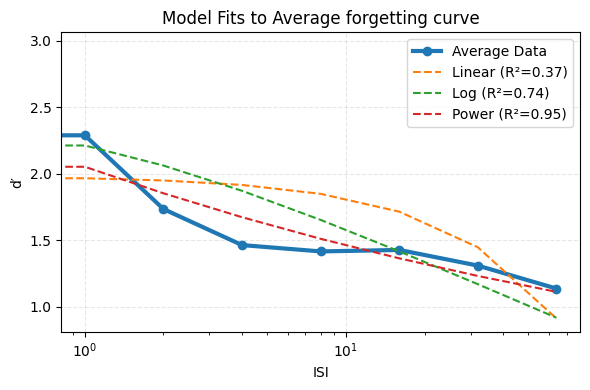

In [34]:
plt.figure(figsize=(6,4))

plt.plot(isi, target, 'o-', label="Average Data", linewidth=3)

plt.plot(isi, pred_lin, '--', label=f"Linear (R²={r2_lin:.2f})")
plt.plot(isi, pred_log, '--', label=f"Log (R²={r2_log:.2f})")
plt.plot(isi, pred_pow, '--', label=f"Power (R²={r2_pow:.2f})")

plt.xscale("log")
plt.xlabel("ISI")
plt.ylabel("d′")
plt.title("Model Fits to Average forgetting curve")
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# ============================================
# Confirm two-regime hypothesis on avg_curve
# small: 0–4, large: 8+
# ============================================

target = avg_curve.copy()          # average forgetting curve
isi     = grid.astype(float)
isi_no0 = np.where(isi == 0, 0.1, isi)   # avoid log(0)

transfer_point=8
# masks for regions
small_mask = isi < transfer_point+1
large_mask = isi >= transfer_point

# -------------------------
# SMALL REGION (0–4)
# -------------------------
isi_s     = isi[small_mask]
isi_no0_s = isi_no0[small_mask]
t_s       = target[small_mask]

# log model: d' = a + b * log(ISI + 1)
X_log_s = np.log(isi_no0_s + 1).reshape(-1,1)
lr = LinearRegression().fit(X_log_s, t_s)
pred_log_s = lr.predict(X_log_s)
r2_log_s = lr.score(X_log_s, t_s)

# power-law: log(d') = A + B * log(ISI)
t_pos_s = np.maximum(t_s, 1e-4)
X_pow_s = np.log(isi_no0_s).reshape(-1,1)
y_pow_s = np.log(t_pos_s)
lr = LinearRegression().fit(X_pow_s, y_pow_s)
pred_pow_log_s = lr.predict(X_pow_s)
pred_pow_s = np.exp(pred_pow_log_s)
r2_pow_s = 1 - np.sum((t_pos_s - pred_pow_s)**2) / np.sum((t_pos_s - np.mean(t_pos_s))**2)

# -------------------------
# LARGE REGION (8–64)
# -------------------------
isi_l     = isi[large_mask]
isi_no0_l = isi_no0[large_mask]
t_l       = target[large_mask]

# log model
X_log_l = np.log(isi_no0_l + 1).reshape(-1,1)
lr = LinearRegression().fit(X_log_l, t_l)
pred_log_l = lr.predict(X_log_l)
r2_log_l = lr.score(X_log_l, t_l)

# power-law model
t_pos_l = np.maximum(t_l, 1e-4)
X_pow_l = np.log(isi_no0_l).reshape(-1,1)
y_pow_l = np.log(t_pos_l)
lr = LinearRegression().fit(X_pow_l, y_pow_l)
pred_pow_log_l = lr.predict(X_pow_l)
pred_pow_l = np.exp(pred_pow_log_l)
r2_pow_l = 1 - np.sum((t_pos_l - pred_pow_l)**2) / np.sum((t_pos_l - np.mean(t_pos_l))**2)

print("\n=== MODEL FITS ON AVERAGE CURVE ===")
print("Small region (ISI 0–4):")
print(f"  Log model R²:    {r2_log_s:.3f}")
print(f"  Power model R²:  {r2_pow_s:.3f}")

print("\nLarge region (ISI 8–64):")
print(f"  Log model R²:    {r2_log_l:.3f}")
print(f"  Power model R²:  {r2_pow_l:.3f}")


=== MODEL FITS ON AVERAGE CURVE ===
Small region (ISI 0–4):
  Log model R²:    0.885
  Power model R²:  0.942

Large region (ISI 8–64):
  Log model R²:    0.850
  Power model R²:  0.813


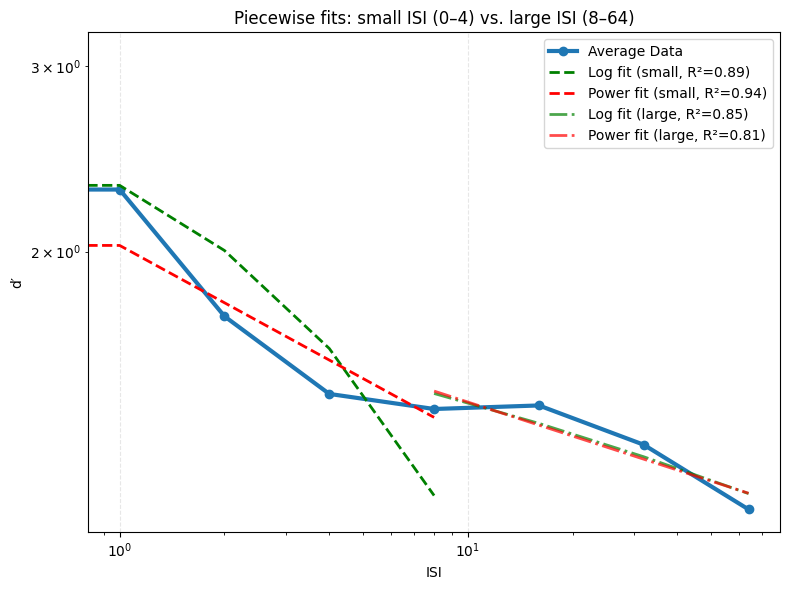

In [45]:
# ============================================
# PLOT SMALL REGION and LARGE REGION FITS
# ============================================

plt.figure(figsize=(8,6))

# average curve
plt.plot(isi, target, 'o-', linewidth=3, label="Average Data", color="#1f77b4")

# -------------------------
# SMALL REGION FITS
# -------------------------
# sort by ISI to ensure smooth plotting
idx_s = np.argsort(isi_s)

plt.plot(
    isi_s[idx_s], pred_log_s[idx_s],
    '--', linewidth=2,
    color="green",
    label=f"Log fit (small, R²={r2_log_s:.2f})"
)

plt.plot(
    isi_s[idx_s], pred_pow_s[idx_s],
    '--', linewidth=2,
    color="red",
    label=f"Power fit (small, R²={r2_pow_s:.2f})"
)

# -------------------------
# LARGE REGION FITS
# -------------------------
idx_l = np.argsort(isi_l)

plt.plot(
    isi_l[idx_l], pred_log_l[idx_l],
    '-.', linewidth=2,
    color="green",
    alpha=0.7,
    label=f"Log fit (large, R²={r2_log_l:.2f})"
)

plt.plot(
    isi_l[idx_l], pred_pow_l[idx_l],
    '-.', linewidth=2,
    color="red",
    alpha=0.7,
    label=f"Power fit (large, R²={r2_pow_l:.2f})"
)

# -------------------------
# FORMAT
# -------------------------
plt.xscale("log")
plt.xlabel("ISI")
plt.yscale("log")

plt.ylabel("d′")
plt.title("Piecewise fits: small ISI (0–4) vs. large ISI (8–64)")
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# import numpy as np

# subjects = x["subject"].unique()
# np.random.seed(0)    # for reproducibility
# np.random.shuffle(subjects)

# half = len(subjects) // 2
# subA = subjects[:half]
# subB = subjects[half:]

# xA = x[x["subject"].isin(subA)].copy()
# xB = x[x["subject"].isin(subB)].copy()

# outA = run_analysis(xA)
# outB = run_analysis(xB)

# plt.figure(figsize=(7,5))

# # ---- Split A ----
# plt.errorbar(
#     outA["isis"],
#     outA["dprime"],
#     yerr=outA["boot"]["sem"],
#     fmt='o-',
#     capsize=3,
#     linewidth=2,
#     markersize=6,
#     label=f"Split A (N={outA['N']})"
# )

# # ---- Split B ----
# plt.errorbar(
#     outB["isis"],
#     outB["dprime"],
#     yerr=outB["boot"]["sem"],
#     fmt='s-',
#     capsize=3,
#     linewidth=2,
#     markersize=6,
#     label=f"Split B (N={outB['N']})"
# )
# isi_random_plot_dir = os.path.join(save_dir, "dprime-vs-isi_random-split.png")

# plt.xticks(outA["isis"], outA["isis"])
# plt.ylim(bottom=0)
# plt.xlabel("Inter-Stimulus Interval (ISI)")
# plt.ylabel("d′ (Sensitivity)")
# plt.title(f"{hr_task_name[which_task]}: d′ vs ISI")
# plt.grid(True, ls="--", alpha=0.4)
# plt.legend()
# plt.tight_layout()
# plt.savefig(isi_random_plot_dir)
# plt.show()


In [26]:
# import numpy as np

# plt.figure(figsize=(7,5))

# # ---- Split A ----
# plt.errorbar(
#     out_beginner["isis"],
#     out_beginner["dprime"],
#     yerr=out_beginner["boot"]["sem"],
#     fmt='o-',
#     capsize=3,
#     linewidth=2,
#     markersize=6,
#     label=f"Non-musicians (N={out_beginner['N']})"
# )

# # ---- Split B ----
# plt.errorbar(
#     out_experienced["isis"],
#     out_experienced["dprime"],
#     yerr=out_experienced["boot"]["sem"],
#     fmt='s-',
#     capsize=3,
#     linewidth=2,
#     markersize=6,
#     label=f"Musicians (>3 years) (N={out_experienced['N']})"
# )
# isi_musician_plot_dir = os.path.join(save_dir, "dprime-vs-isi_musician_split.png")

# plt.xticks(out_experienced["isis"], out_experienced["isis"])
# plt.ylim(bottom=0)
# plt.xlabel("Inter-Stimulus Interval (ISI)")
# plt.ylabel("d′ (Sensitivity)")
# plt.title(f"{hr_task_name[which_task]}: d′ vs ISI")
# plt.grid(True, ls="--", alpha=0.4)
# plt.legend()
# plt.tight_layout()
# plt.savefig(isi_musician_plot_dir)
# plt.show()


In [27]:
# from collections import defaultdict

# freq_dict = defaultdict(int)
# for exp in exps:
#     for i in exp.index:
#         if exp.loc[i].isi == 16:
#             current_stim = exp.loc[i].stimulus.split("/")[-1]
#             freq_dict[current_stim] += 1

In [28]:
# import re

# freq_dict = defaultdict(int)
# for exp in exps:
#     for i in exp.index:
#         if exp.loc[i].isi == 16:
#             current_stim = exp.loc[i].stimulus.split("/")[-1]
#             freq_dict[current_stim] += 1
            
# # --- extract integers ---
# stim_ids = []
# counts = []

# for k, v in freq_dict.items():
#     n = int(re.findall(r"\d+", k)[-1])  # extract final integer
#     stim_ids.append(n)
#     counts.append(v)

# # --- sort by stim id ---
# stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# # --- bar plot ---
# plt.figure(figsize=(7,4))
# plt.bar(stim_ids, counts)
# plt.xlabel("Stimulus ID")
# plt.ylabel("Count")
# plt.xticks(stim_ids[::10])
# plt.title(f"Histogram of Stimuli frequencies counts (FOR ISI={16}) (N={N})")
# plt.tight_layout()
# plt.show()

In [29]:
# freq_dict = defaultdict(int)
# isi_choice =8
# for exp in exps:
#     for i in exp.index:
#         if exp.loc[i].isi == isi_choice:
#             current_stim = exp.loc[i].stimulus.split("/")[-1]
#             freq_dict[current_stim] += 1

# # --- extract integers ---
# stim_ids = []
# counts = []

# for k, v in freq_dict.items():
#     n = int(re.findall(r"\d+", k)[-1])  # extract final integer
#     stim_ids.append(n)
#     counts.append(v)

# # --- sort by stim id ---
# stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# # --- bar plot ---
# plt.figure(figsize=(7,4))
# plt.bar(stim_ids, counts)
# plt.xlabel("Stimulus ID")
# plt.ylabel("Count")
# plt.xticks(stim_ids[::10])
# plt.title(f"Histogram of Stimuli frequencies counts (FOR ISI={isi_choice}) (N={N}) (total={np.sum(counts)})")
# plt.tight_layout()
# plt.show()

In [30]:
# plt.figure(figsize=(8,5))

# freq_dict_isi = defaultdict(dict)
# all_possible_ids = set()

# # Collect all stim IDs first
# for exp in exps:
#     for i in exp.index:
#         current_stim = exp.loc[i].stimulus.split("/")[-1]
#         sid = int(re.findall(r"\d+", current_stim)[-1])
#         all_possible_ids.add(sid)

# all_possible_ids = np.array(sorted(all_possible_ids))

# for j in [0,1,2,4,8,16,32,64]:

#     # count frequencies
#     freq_dict = defaultdict(int)
#     for exp in exps:
#         for i in exp.index:
#             if exp.loc[i].isi == j:
#                 current_stim = exp.loc[i].stimulus.split("/")[-1]
#                 sid = int(re.findall(r"\d+", current_stim)[-1])
#                 freq_dict[sid] += 1

#     freq_dict_isi[j] = freq_dict

#     # fill vector over full range
#     counts = np.array([freq_dict[sid] for sid in all_possible_ids])

#     # plot curve
#     plt.plot(all_possible_ids, counts, label=f"ISI {j}", linewidth=2, alpha=0.5)

# plt.legend()
# plt.xlabel("Stimulus ID")
# plt.ylabel("Count")
# plt.ylim(bottom=0)
# plt.xticks(all_possible_ids[::10])
# plt.title(f"Histogram of Stimuli repeat frequencies counts across all ISIs ($N_{{sequences}}$={N})")
# plt.tight_layout()
# plt.show()


In [31]:
# stim_dict = defaultdict(int)

# for isi in freq_dict_isi:
#     freq_dict = freq_dict_isi[isi]

#     for stim in freq_dict:
#        stim_dict[stim]+= freq_dict[stim]


# # --- extract integers ---
# stim_ids = []
# counts = []

# for k, v in stim_dict.items():
#     stim_ids.append(k)
#     counts.append(v)

# # --- sort by stim id ---
# stim_ids, counts = zip(*sorted(zip(stim_ids, counts)))

# # --- bar plot ---
# plt.bar(stim_ids, counts, alpha=0.4)

# plt.xlabel("Stimulus ID")
# plt.ylabel("Count")
# plt.xticks(stim_ids[::10])
# plt.title(f"Histogram of Stimuli repeat frequencies counts across all ISIs ($N_{"{sequences}"}$={N})")
# plt.tight_layout()
# plt.show()

In [32]:
# freq_dict